In [12]:
import warnings
warnings.filterwarnings('ignore') # ignore scikit-learn runtime warnings

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron

# create images directory
os.makedirs('images', exist_ok=True)

In [13]:
# load the banknote dataset
df = pd.read_csv('data/data_banknote_authentication.txt', names=["Variance", "Skewness", "Curtosis", "Entropy", "Class"])
print(df.head())
print(df.shape)
print(df.isnull().sum())
print(df.describe())

   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
(1372, 5)
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.

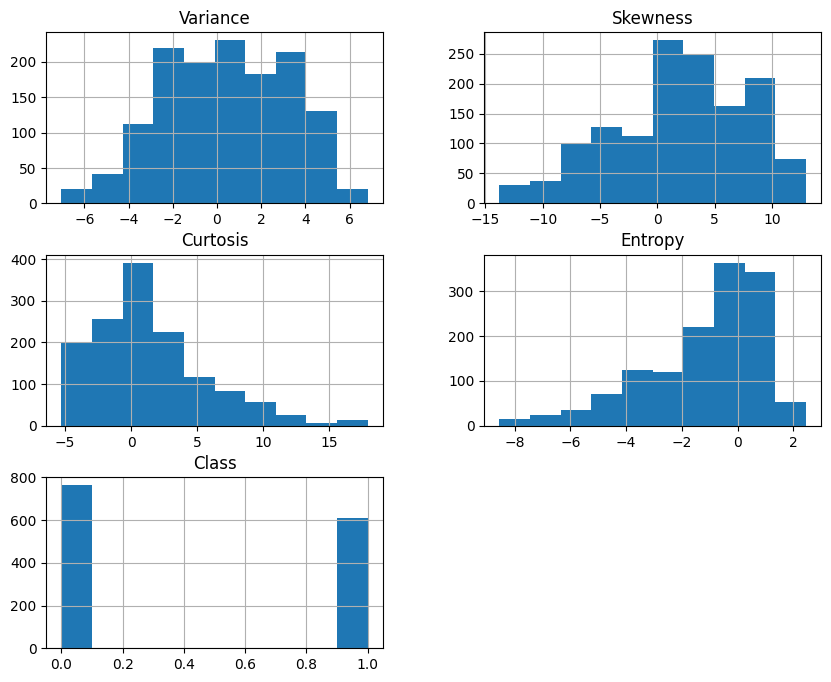

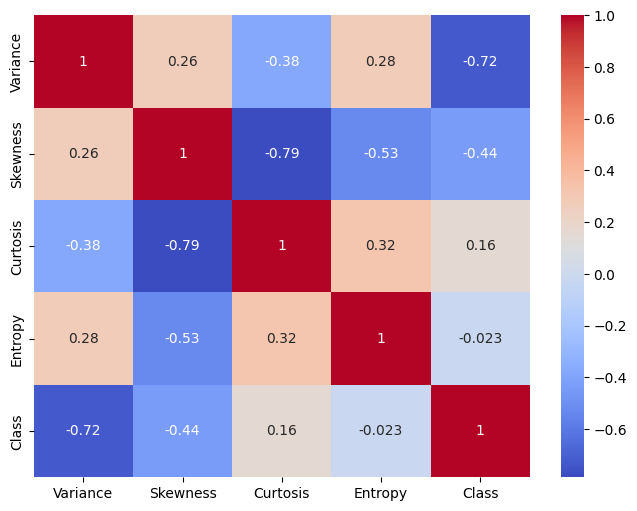

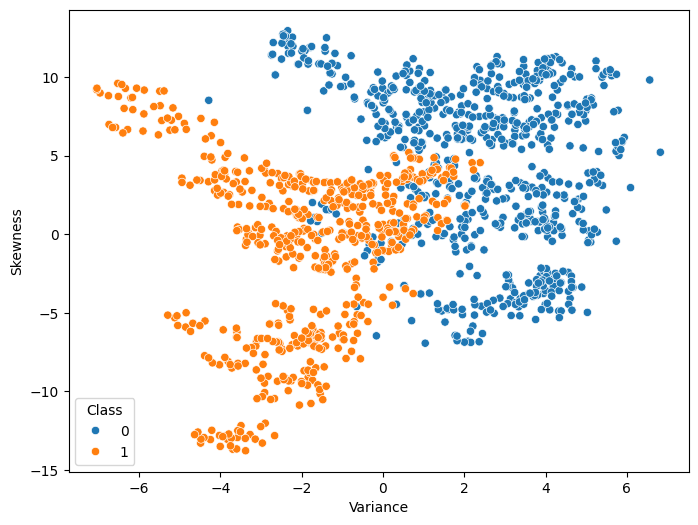

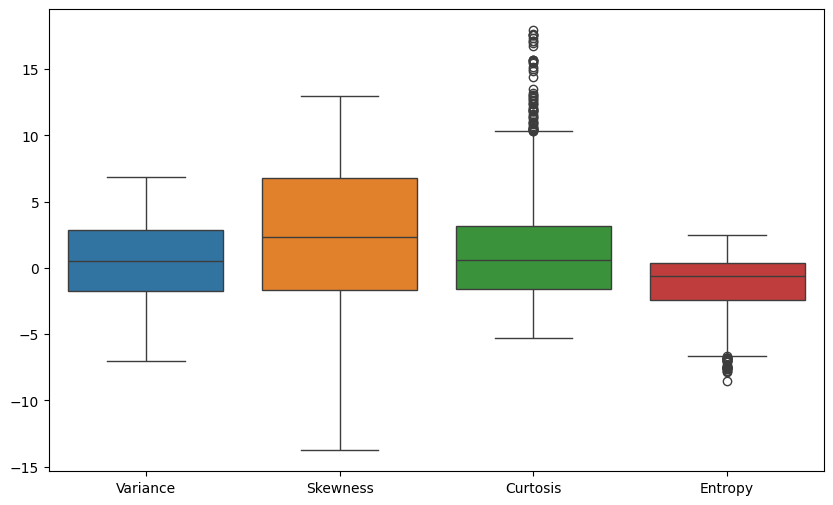

In [14]:
# visualize data distributions and correlations
df.hist(figsize=(10, 8))
plt.savefig('images/feature_histograms.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Variance', y='Skewness', hue='Class', data=df)
plt.savefig('images/scatter_plot.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('Class', axis=1))
plt.savefig('images/boxplots.png', bbox_inches='tight')
plt.show()

In [15]:
# preprocessing: normalization and train-test split
X = df.drop('Class', axis=1).values
y = df['Class'].values
X = (X - X.mean(axis=0)) / X.std(axis=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
class SingleLayerPerceptron:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.errors = []
        
    def fit(self, X, y):
        # initialize weights and bias
        self.w = np.zeros(X.shape[1])
        self.b = 0
        
        # training loop
        for _ in range(self.epochs):
            err = 0
            for xi, target in zip(X, y):
                # forward pass with step activation
                pred = 1 if np.dot(xi, self.w) + self.b >= 0 else 0
                
                # weight and bias update
                update = self.lr * (target - pred)
                self.w += update * xi
                self.b += update
                err += int(update != 0)
            self.errors.append(err)
            
    def predict(self, X):
        return np.where(np.dot(X, self.w) + self.b >= 0, 1, 0)

# train our custom model
model = SingleLayerPerceptron(lr=0.01, epochs=50)
model.fit(X_train, y_train)

print(model.w)
print(model.b)

[-0.19659468 -0.21935072 -0.21065944 -0.01847794]
-0.09999999999999999


Accuracy: 0.9781818181818182
Precision: 0.984
Recall: 0.968503937007874
F1-score: 0.9761904761904762


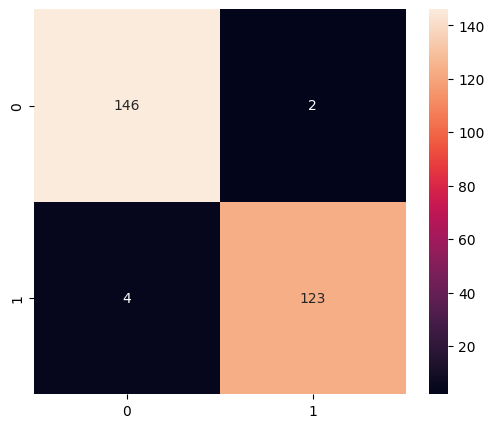

In [17]:
# evaluate predictions
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-score:", f1_score(y_test, preds))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d')
plt.savefig('images/confusion_matrix.png', bbox_inches='tight')
plt.show()

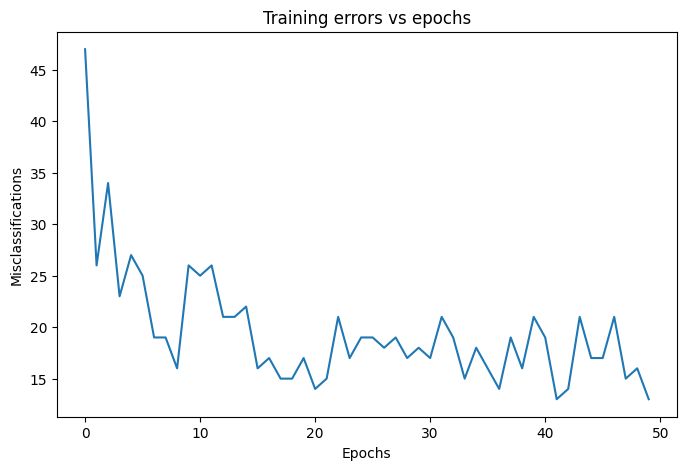

In [18]:
# plot errors over time
plt.figure(figsize=(8, 5))
plt.plot(model.errors)
plt.title('Training errors vs epochs')
plt.xlabel('Epochs')
plt.ylabel('Misclassifications')
plt.savefig('images/training_errors.png', bbox_inches='tight')
plt.show()

Sklearn accuracy: 0.9672727272727273


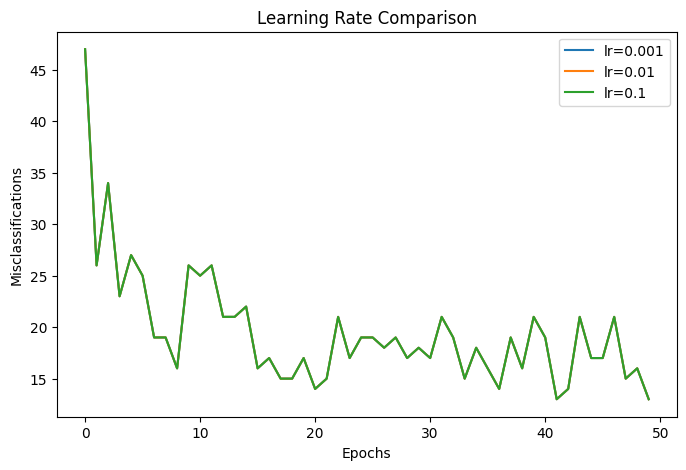

In [19]:
# compare with sklearn and test different learning rates
sk_model = Perceptron(eta0=0.01, max_iter=50)
sk_model.fit(X_train, y_train)
print("Sklearn accuracy:", accuracy_score(y_test, sk_model.predict(X_test)))

plt.figure(figsize=(8, 5))
for lr in [0.001, 0.01, 0.1]:
    m = SingleLayerPerceptron(lr=lr, epochs=50)
    m.fit(X_train, y_train)
    plt.plot(m.errors, label=f'lr={lr}')
plt.title('Learning Rate Comparison')
plt.xlabel('Epochs')
plt.ylabel('Misclassifications')
plt.legend()
plt.savefig('images/learning_rate_comparison.png', bbox_inches='tight')
plt.show()